# Evaluation

This notebook brings the three tuned candidates from `04_modelling_classical.ipynb` and `05_modelling_lstm.ipynb` together: the two classical models are rebuilt from their own best hyperparameters, and the LSTM candidate is loaded instead of being retrained since its training is stochastic and the model deployed must be the exact one already evaluated.

The three are compared on the validation set using one explicit selection rule. The winner is calibrated if it is the Linear SVM (it has no `predict_proba` on its own), evaluated once on the held-out test set, checked against a small, AI-generated adversarial stress test, explained on a few individual predictions, and saved as `models/deployed_pipeline.joblib` for the app to load.

In [1]:
# Standard library
import sys

# Third-party
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.frozen import FrozenEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC

# Make the repository root importable so src/ can be reached from notebooks/
sys.path.append("..")

# Local
from src.clean_text import clean_text
from src.explain import explain_prediction

# Show every column when previewing a DataFrame, instead of truncating with "..."
pd.set_option("display.max_columns", None)

# A fixed seed used for every split, reused from 04_modelling_classical.ipynb and 05_modelling_lstm.ipynb so this notebook reproduces the exact same train/validation/test split.
RANDOM_STATE = 42

## Load Data and Reproduce the Split

The same cleaned dataset and the same two `train_test_split` calls used in `04_modelling_classical.ipynb` and `05_modelling_lstm.ipynb` are repeated here with the same `RANDOM_STATE`, producing identical training, validation, and test rows as both notebooks. This is the only way all three models are compared on the same data, since no notebook shares kernel state with another.

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/cleaned.csv")

# Separate the features from the label
X = df.drop(columns=["fraudulent"])
y = df["fraudulent"]

# First split: 70% train, 30% held out for validation and test combined
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

# Second split: the 30% holdout is split evenly into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.50, stratify=y_holdout, random_state=RANDOM_STATE)

# Report the size and class balance of each split
for name, split_y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    fraud_rate = split_y.mean() * 100
    print(f"{name}: {len(split_y)} rows, {fraud_rate:.2f}% fraudulent")

Train: 12516 rows, 4.84% fraudulent
Validation: 2682 rows, 4.85% fraudulent
Test: 2682 rows, 4.85% fraudulent


## Rebuild the Classical Candidates, Load the LSTM Candidate

`build_preprocessor()` is copied verbatim from `04_modelling_classical.ipynb`, since it is defined inside that notebook and this notebook runs in a separate kernel that never sees it. The two classical models are then rebuilt once each using the best hyperparameters `04_modelling_classical.ipynb` already found independently for each: `logistic_regression_search.best_params_` for Logistic Regression and `svm_search.best_params_` for the Linear SVM.

Both currently happen to be `C=10, max_features=5000, ngram_range=(1, 1)`, but each is sourced from its own recorded search instead of being assumed to match, since a future re-tune of one should not silently affect the other.

In [3]:
# The six metadata columns to one-hot encode, copied verbatim from 04_modelling_classical.ipynb
metadata_fields = ["department", "employment_type", "required_experience", "required_education", "industry", "function"]


def build_preprocessor():
    """Return a fresh, unfitted ColumnTransformer for the text and metadata columns."""
    return ColumnTransformer(
        transformers=[
            ("text", TfidfVectorizer(), "text"),
            ("categorical", OneHotEncoder(handle_unknown="ignore"), metadata_fields),
        ],
        remainder="passthrough",
    )

The classification report, ROC-AUC, and confusion matrix are printed for every candidate in the same way, so a single `report` function (defined here, local to this notebook only) replaces the block copy-pasted three times across `04_modelling_classical.ipynb` and `05_modelling_lstm.ipynb`. It also returns the fraudulent class's precision, recall, and F1 alongside the ROC-AUC, which are collected into the comparison table below.

In [4]:
def report(y_true, y_pred, y_scores, title):
    """Print a classification report, ROC-AUC, and confusion matrix, and return the fraudulent class's metrics."""
    print(f"--- {title} ---\n")
    print(classification_report(y_true, y_pred))
    roc_auc = roc_auc_score(y_true, y_scores)
    print(f"ROC-AUC: {roc_auc:.4f}")

    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Legitimate", "Fraudulent"], ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    plt.show()

    fraud_metrics = classification_report(y_true, y_pred, output_dict=True)["1"]
    return {"precision": fraud_metrics["precision"], "recall": fraud_metrics["recall"], "f1": fraud_metrics["f1-score"], "roc_auc": roc_auc}

### Logistic Regression

Rebuilt at its own best hyperparameters (`C=10, max_features=5000, ngram_range=(1, 1)`) from `logistic_regression_search.best_params_` in `04_modelling_classical.ipynb`, fit once on the training set, and evaluated on the validation set. `predict_proba` gives a calibrated score directly.

--- Logistic Regression ---

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2552
           1       0.78      0.91      0.84       130

    accuracy                           0.98      2682
   macro avg       0.89      0.95      0.91      2682
weighted avg       0.98      0.98      0.98      2682

ROC-AUC: 0.9944


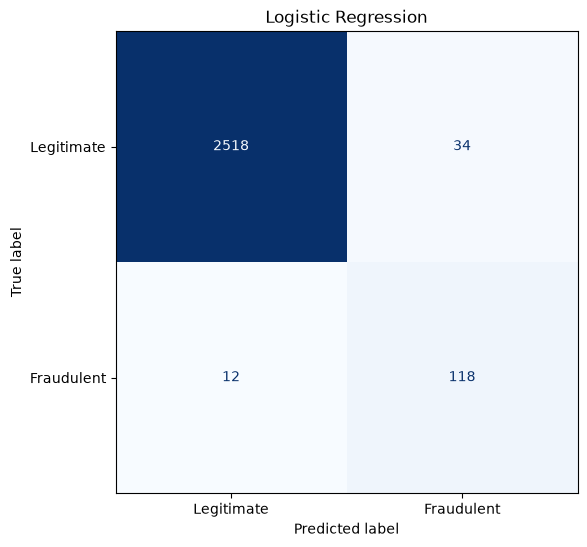

In [5]:
# Rebuild Logistic Regression at its own best hyperparameters from 04_modelling_classical.ipynb and fit once on the training set
logistic_regression_pipeline = Pipeline([("preprocessor", build_preprocessor()), ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE, C=10))])
logistic_regression_pipeline.set_params(preprocessor__text__max_features=5000, preprocessor__text__ngram_range=(1, 1))
logistic_regression_pipeline.fit(X_train, y_train)

logistic_regression_predictions = logistic_regression_pipeline.predict(X_val)
logistic_regression_scores = logistic_regression_pipeline.predict_proba(X_val)[:, 1]
logistic_regression_metrics = report(y_val, logistic_regression_predictions, logistic_regression_scores, "Logistic Regression")

### Linear SVM

Rebuilt independently at its own best hyperparameters from `svm_search.best_params_` in `04_modelling_classical.ipynb`. `LinearSVC` has no `predict_proba`, so `decision_function` is used for the ROC-AUC ranking score here, exactly as in `04_modelling_classical.ipynb`. Turning this into a calibrated probability only happens later on if this variant wins.

--- Linear SVM ---

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2552
           1       0.85      0.85      0.85       130

    accuracy                           0.99      2682
   macro avg       0.92      0.92      0.92      2682
weighted avg       0.99      0.99      0.99      2682

ROC-AUC: 0.9927


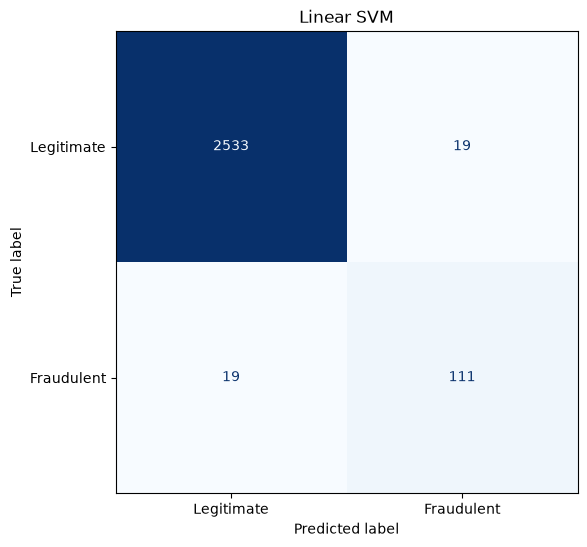

In [6]:
# Rebuild the Linear SVM at its own best hyperparameters from 04_modelling_classical.ipynb and fit once on the training set
svm_pipeline = Pipeline([("preprocessor", build_preprocessor()), ("classifier", LinearSVC(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE, C=10))])
svm_pipeline.set_params(preprocessor__text__max_features=5000, preprocessor__text__ngram_range=(1, 1))
svm_pipeline.fit(X_train, y_train)

svm_predictions = svm_pipeline.predict(X_val)
svm_scores = svm_pipeline.decision_function(X_val)
svm_metrics = report(y_val, svm_predictions, svm_scores, "Linear SVM")

### LSTM

Loaded from `models/lstm_candidate.joblib`, the exact object `05_modelling_lstm.ipynb` trained and evaluated (not retrained here). Its metrics below should match `05_modelling_lstm.ipynb`'s reported validation numbers exactly since this is the same fitted object and not a rebuild.

84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
--- LSTM ---

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2552
           1       0.86      0.88      0.87       130

    accuracy                           0.99      2682
   macro avg       0.93      0.93      0.93      2682
weighted avg       0.99      0.99      0.99      2682

ROC-AUC: 0.9803


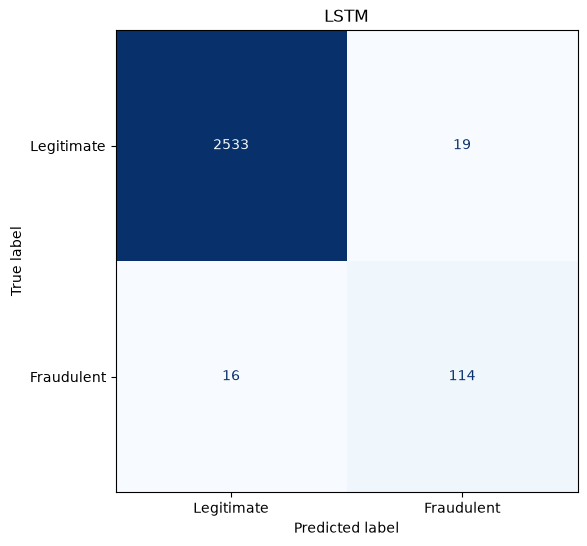

In [7]:
# Load the exact LSTM object 05_modelling_lstm.ipynb trained and evaluated instead of retraining it here
lstm_pipeline = joblib.load("../models/lstm_candidate.joblib")

lstm_scores = lstm_pipeline.predict_proba(X_val["text"])[:, 1]
lstm_predictions = (lstm_scores >= 0.5).astype(int)
lstm_metrics = report(y_val, lstm_predictions, lstm_scores, "LSTM")

## Compare Candidates and Select a Winner

The three candidates' validation metrics are placed in one table, alongside an overlaid ROC curve.

The selection rule is explicit: **F1 on the fraudulent class is the primary metric**, matching the class-imbalance justification from `03_eda.ipynb`. **ROC-AUC is the secondary metric**. If the top two candidates by F1 are within 0.01 of each other on both F1 and ROC-AUC, the classical model between them wins the tie, since it is smaller, faster, and directly explainable. Otherwise, the highest-F1 candidate wins outright.

In [8]:
# Collect the three candidates' validation metrics into one comparison table
comparison = pd.DataFrame(
    {
        "Logistic Regression": logistic_regression_metrics,
        "Linear SVM": svm_metrics,
        "LSTM": lstm_metrics,
    }
).T
comparison

,precision,recall,f1,roc_auc
Logistic Regression,0.776316,0.907692,0.836879,0.994442
Linear SVM,0.853846,0.853846,0.853846,0.992681
LSTM,0.857143,0.876923,0.866920,0.980281


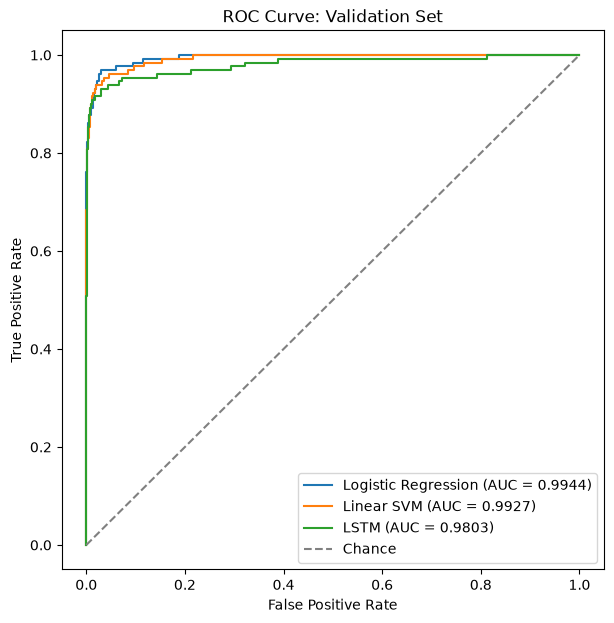

In [9]:
# Overlay all three candidates' ROC curves on the validation set
fig, ax = plt.subplots(figsize=(7, 7))
for name, scores in [("Logistic Regression", logistic_regression_scores), ("Linear SVM", svm_scores), ("LSTM", lstm_scores)]:
    false_positive_rate, true_positive_rate, _ = roc_curve(y_val, scores)
    ax.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC = {roc_auc_score(y_val, scores):.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: Validation Set")
ax.legend()
plt.show()

In [10]:
# Apply the selection rule: highest F1 wins outright, unless the top two are within 0.01 on both F1 and ROC-AUC, in which case a classical model beats a narrowly-better LSTM
candidate_metrics = {"Logistic Regression": logistic_regression_metrics, "Linear SVM": svm_metrics, "LSTM": lstm_metrics}
classical_names = {"Logistic Regression", "Linear SVM"}

ranked_candidates = sorted(candidate_metrics.items(), key=lambda item: item[1]["f1"], reverse=True)
top_name, top_metrics = ranked_candidates[0]
runner_up_name, runner_up_metrics = ranked_candidates[1]

f1_gap = top_metrics["f1"] - runner_up_metrics["f1"]
roc_auc_gap = abs(top_metrics["roc_auc"] - runner_up_metrics["roc_auc"])
is_narrow_tie = f1_gap <= 0.01 and roc_auc_gap <= 0.01

if is_narrow_tie and top_name not in classical_names and runner_up_name in classical_names:
    winner_name = runner_up_name
else:
    winner_name = top_name

print(f"Winner: {winner_name}")

Winner: LSTM


## Calibrate, If the Winner Is the SVM

Logistic Regression and the LSTM both already expose `predict_proba`. However, the Linear SVM does not. Hence if it wins, it is wrapped in `CalibratedClassifierCV` to turn its decision-function margin into a probability the app's confidence score needs.

The already-fitted pipeline is wrapped in `sklearn.frozen.FrozenEstimator` so it is used as-is instead of being refit, and the calibrator itself is fit on the **validation set** only and never on train (already used to fit the SVM) or test. 

From here on, "the winner" refers to this calibrated object.

In [11]:
# Select the winning object, calibrating it on the validation set only if the winner is the uncalibrated SVM
candidate_pipelines = {"Logistic Regression": logistic_regression_pipeline, "Linear SVM": svm_pipeline, "LSTM": lstm_pipeline}
winner = candidate_pipelines[winner_name]

if winner_name == "Linear SVM":
    winner = CalibratedClassifierCV(FrozenEstimator(winner), method="sigmoid")
    winner.fit(X_val, y_val)
    print("Calibrated the Linear SVM on the validation set.")
else:
    print(f"{winner_name} already provides predict_proba. No calibration needed.")

LSTM already provides predict_proba. No calibration needed.


## Evaluate the Winner on the Test Set

This is the **only** place `X_test`/`y_test` are touched anywhere across `04_modelling_classical.ipynb`, `05_modelling_lstm.ipynb`, and this notebook. It is run exactly once on the final winner.

A small helper predicts with whichever model won: the classical pipelines (calibrated or not) expect the full feature DataFrame, while the LSTM only ever sees the `text` column.

84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
--- LSTM (Test Set) ---

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2552
           1       0.82      0.82      0.82       130

    accuracy                           0.98      2682
   macro avg       0.90      0.90      0.90      2682
weighted avg       0.98      0.98      0.98      2682

ROC-AUC: 0.9687


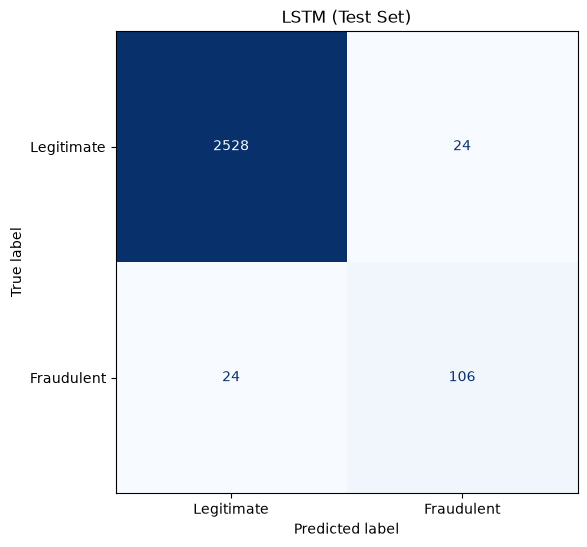

In [12]:
def winner_predict_proba(X_frame):
    """Return the winner's fraud probabilities, whether it expects the full feature DataFrame or the text column only."""
    if winner_name == "LSTM":
        return winner.predict_proba(X_frame["text"])[:, 1]
    return winner.predict_proba(X_frame)[:, 1]


# Predict on the test set exactly once and report the winner's final performance
test_scores = winner_predict_proba(X_test)
test_predictions = (test_scores >= 0.5).astype(int)
test_metrics = report(y_test, test_predictions, test_scores, f"{winner_name} (Test Set)")

## Run the Stress Test

`data/stress_test.csv` is a small, AI-generated adversarial set of harder postings. Each already contains a single consolidated `text` column instead of the five raw fields `combine_fields` expects. Hence, `clean_text` alone is applied directly to the `text` column, mirroring how a single pasted posting will be cleaned by the app, and predictions use that cleaned text plus the file's own metadata columns.

With only 36 rows, results are discussed qualitatively instead of being treated as a formal metric.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
--- LSTM (Stress Test) ---

              precision    recall  f1-score   support

           0       0.64      0.89      0.74        18
           1       0.82      0.50      0.62        18

    accuracy                           0.69        36
   macro avg       0.73      0.69      0.68        36
weighted avg       0.73      0.69      0.68        36

ROC-AUC: 0.6358


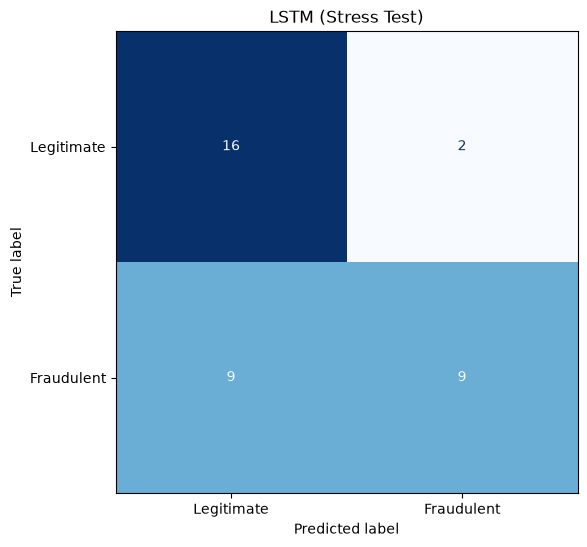

In [13]:
# Load the stress test set and clean its already-consolidated text column directly, since it has no raw fields for combine_fields to join
stress_df = pd.read_csv("../data/stress_test.csv")
stress_df["text"] = stress_df["text"].apply(clean_text)

# The stress set has no department/industry/function columns. Fill them with the same placeholder used for missing categories in 02_data_preparation.ipynb
for column in ["department", "industry", "function"]:
    stress_df[column] = "missing"

stress_scores = winner_predict_proba(stress_df)
stress_predictions = (stress_scores >= 0.5).astype(int)
stress_metrics = report(stress_df["fraudulent"], stress_predictions, stress_scores, f"{winner_name} (Stress Test)")

## Explain a Few Predictions

`explain_prediction` from `src/explain.py` is demonstrated on one test-set posting and one stress-test posting, printing the words that most pushed each prediction toward or away from "fraudulent". This exercises the module end to end against whichever model actually won, not just against the synthetic examples in `tests/test_explain.py`.

In [14]:
# Explain one test-set posting and one stress-test posting with the winning model
test_example_text = X_test["text"].iloc[0]
stress_example_text = stress_df["text"].iloc[0]

for label, text in [("Test set example", test_example_text), ("Stress test example", stress_example_text)]:
    print(f"--- {label} ---")
    for word, contribution in explain_prediction(winner, text, top_n=10):
        print(f"{word}: {contribution:+.4f}")
    print()

--- Test set example ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
university: -0.0007
eligible: -0.0006
certification: +0.0004
elementary: +0.0003
education: +0.0002
major: +0.0002
accredited: -0.0002
elementary: +0.0001
in: +0.0001
andvirgin: +0.0001

--- Stress test example ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
setup: -0.0010
continue: -0.0003
hi: +0.0002
then: +0.0002
m: -0.0002
on: +0.0001
me: +0.0001
the: +0.0001
recruiter: -0.0001
telegram: +0.0001



## Save the Deployed Pipeline

The winner is saved as `models/deployed_pipeline.joblib` in a single `joblib.dump` call regardless of its type. This is the one artifact the app loads.

In [15]:
# Save the winner as the single deployed pipeline artifact
joblib.dump(winner, "../models/deployed_pipeline.joblib")

['../models/deployed_pipeline.joblib']

## Summary

- All three candidates were rebuilt or loaded and evaluated on the same validation split: Logistic Regression (0.78 precision, 0.91 recall, 0.84 F1, 0.9944 ROC-AUC), Linear SVM (0.85 precision, 0.85 recall, 0.85 F1, 0.9927 ROC-AUC), and the LSTM loaded from `models/lstm_candidate.joblib` (0.86 precision, 0.88 recall, 0.87 F1, 0.9803 ROC-AUC). The Logistic Regression and SVM numbers match `04_modelling_classical.ipynb`'s reported figures exactly, and the LSTM's match `05_modelling_lstm.ipynb`'s exactly, confirming both the classical rebuilds and the LSTM load are faithful.
- The selection rule (F1 primary, ROC-AUC secondary, classical wins a tie within 0.01 on both) picked the **LSTM** outright: its F1 (0.87) leads the runner-up, the Linear SVM (0.85), by 0.013, past the 0.01 tie margin, so no tie-break applied.
- The LSTM already exposes `predict_proba`, so no calibration step was needed.
- Evaluated once on the test set, the LSTM reached 0.82 precision, 0.82 recall, 0.82 F1, and 0.9687 ROC-AUC which is a bit lower than its validation numbers as expected on unseen data, but consistent with the same overall performance level.
- On the 36-row AI-generated adversarial stress test, the LSTM reached 0.82 precision but only 0.50 recall (0.62 F1, 0.6358 ROC-AUC). This is read as a qualitative signal and not a formal metric given how small the sample is. The stress set is deliberately adversarial, and the low recall shows the model misses roughly half of these harder fraudulent postings which look different from the fraud examples it was trained on.
- `explain_prediction` from `src/explain.py` was demonstrated on one test-set and one stress-test posting, printing the LSTM's occlusion-based word contributions for each, exercising the module end to end against the actual deployed model.
- The winner was saved as `models/deployed_pipeline.joblib`.
- `app.py` is the next and final stage, loading `models/deployed_pipeline.joblib`.